# اشتقاق الامامية التفاعلي باستخدام خوارزمية Grabcut:

## الهدف:

** سنتعلم بهذا الفصل: **

* خوارزمية grabcut لاشتقاق الاجسام من الصور.

* سننشئ تطبيق تفاعلي باستخدامها

## النظرية:
الورقة الاصلية خلف هذه الخوارزمية كانت بعنوان : " اشتقاق الامامية التفاعلي باستخدام graph cuts التفاعلية"
حيث كان الهدف ان تتم الخوارزمية باقل تفاعل من المستخدم. 

وطريقة عملها من وجهة نظر المستخدم , هي ان يرسم المستخدم مستطيلاً حول الجسم (الامامية) بحيث يحتوي كامل الجسم .ومن ثم يتكرر تطبيق الخوارزمية حتى الوصول لافضل نتيجة , لكن احياناً قد لا نحصل على النتيجة المرغوبة بسبب الاخطاء الحاصلة عند تعليم الخلفية كامامية او العكس مثلاً..

سنحتاج في هذه الحالة لاعادة تعليم للنتيجة مثلاً التحديد يدوياً بضربات تحدد اماكن الاخطاء بالناتج , وبعدها نحدث لنحصل على نتائج ادق .

حيث كما المثال ادناه , نرسم اولاً مستطيل  حول الجسم ومن ثم هناك لمسات اخيرة باللون الابيض لتحديد الامامية والاسود لتحديد الخلفية ومن ثم نحصل على نتيجة جيدة.

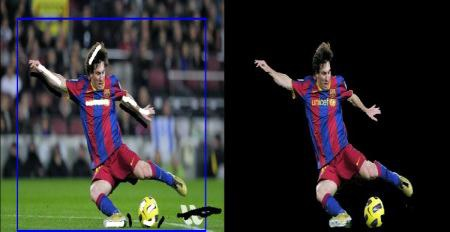

In [1]:
from IPython.display import Image
Image("messi.jpg")

ولكن ما الذي حل بالخلفية ؟

* اولا يرسم المستخدم مستطيل وكل شيء خارجه يعد خلفية اكيدة , ولذلك وجب تضمين الجسم كاملاً ضمنه , واي ادخال كهذا من قبل المستخدم يبقى كذلك بالنتيجة دون تغيير .

* ويقوم الحاسوب بعدها بتحديد اولي حيث الخلفية والامامية اعتماداً على مدخلاتنا.

* يستخدم الان نموذج خلائطي غاوسي GMM لنمذجة الخلفية والامامية.

* تتعلم ال GMM وتنشأ توزعاً جديداً للبكسلات بالاعتماد على البيانات المقدمة , حيث تصنف البكسلات غير المحددة اما كامامية اوخلفية محتملتين , بالاعتماد على علاقاتها مع البكسلات المحددة بدلالة احصاءات الالوان (مثل التجميع بعناقيد)

* ويتم بناء ال graph من توزيع البكسلات هذا وتتمثل العقد بالبكسلات مع اضافة عقدة **المصدر** وترتبط بها بكسلات الامامية وعقدة ** المصرف ** وترتبط بها بكسلات الخلفية .

* اوزان الحواف التي تصل البكسلات بعقدة المنبع/المصرف متناسبة مع احتمالية كون البكسل ينتمي للامامية / الخلفية . تحدد الاوزان بين البكسلات بمعلومات الحافة او تشابه البكسل , فاذا كان هناك فرق كبير بالوان البكسلات المترابطة فالحافة بينهم ستكتسب وزناً اخف.

* وعندها تطبق خوارزمية mincut لتقطيع ال graph . حيث تقطعه لعقدتي منبع ومصرف بتابع كلفة اصغري. وتابع الكلفة هو مجموع كل اوزان الحواف المقطوعة , وبعد القطع تقسم كل البكسلات اما لامامية او لخلفية حسب ارتباطها.

* تستمر العملية حتى تقارب التصنيف .

يتم توضيح العملية بالصورة التالية

<img src='http://www.cs.ru.ac.za/research/g02m1682/Research_files/image002.jpg'>

## مثال:

ان تطبيق خوارزمية Grab cut في OpenCV يتم عن طريق التابع cv2.grabcut حيث متغيراته:

* img : الصورة الاصل

* mask : القناع للصورة والذي يحدد المناطق الامامية والخلفية أو احتماليتها , وهذا يتم بالاعلام التالية : cv2.GC_BGD , cv2.GC_FGD , cv2.GC_PR_BGD ,cv2.GC_PR_FGD. او نمرر 0,1,2,3 على الترتيب ببساطة .

* rect: وهي احداثيات المستطيل المحيط بالامامية بصيغة (x,y,w,h).

* fgdModel , bgdModel : وهي مصفوفات تستخدمها الخوارزمية داخلياً , يمكنك فقط تمرير مصفوفات صفرية بصيغة np.float64 وبحجم (1,65).

* iter_count : عدد المرات التي يجب تكرار الخوارزمية فيها.

* mode : يمكن ان تكون cv2.GC_INIT_WITH_RECT , cv2.GC_INIT_WITH_MASK او وضعاً مركباً والذي يحدد ما اذا كان سيتم رسم مستطيل او لمسات اخيرة معدلة.


أولا سنبدأ بوضع المستطيل حيث : نحمل الصورة , وننشئ قناعاً مماثلاً وكذلك ننشأ fgdModel , bgdModel , ويعطي بارامترات المستطيل وهذا كله مباشر , لنفرض اننا سنشغل الخوارزمية ل 5 مرات .

وال Mode يجب ان يكون cv2.GC_INIT_WITH_RECT بما اننا نبدأ بمستطيل ومن ثم نشغل ال grabcut.

وفي الصورة الجديدة المعدلة للقناع ستكون البكسلات معدلة ب 4 أعلام , محددة اما للخلفية أو الامامية كما أعلاه.

وبعدها نعدله بحيث ان البكسلات بأرقام 0 أو 2 تكون خلفية اكيدة , 
اما البكسلات بارقام 1 و 3 تكون امامية اكيدة , وبعد جهوز القناع نضربه بالصورة الاصلية لنحصل على نتيجة التقطيع المرغوية كالكود التالي:

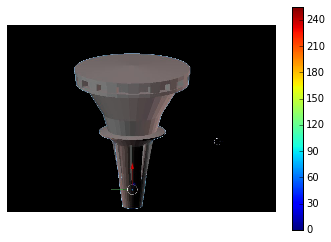

In [5]:
import numpy as np
import cv2
from matplotlib import pyplot as plt
%matplotlib inline

img = cv2.imread('wt.jpg')
mask = np.zeros(img.shape[:2],np.uint8)

bgdModel = np.zeros((1,65),np.float64)
fgdModel = np.zeros((1,65),np.float64)

rect = (150,60,600,566)
cv2.grabCut(img,mask,rect,
            bgdModel,fgdModel,5,cv2.GC_INIT_WITH_RECT)

mask2 = np.where((mask==2)|(mask==0),0,1).astype('uint8')
img = img*mask2[:,:,np.newaxis]

plt.imshow(img),plt.colorbar(),plt.xticks([])
plt.yticks([])
plt.show()
None

لنلحظ النتيجة , نرى بانها جيدة ولكن هناك بعض المشاكل مثلاً دائرة على اليسار وايضاً الاسهم بالاسفل , اذا اردنا تحسينها علينا  استخدام الطريقة الثانيةوتكون بتحديد القناع اولاً , عبر اداة خاصة حيث نحدد الاجسام الامامية الاكيدة باللون الابيض والخلفية الاكيدة بالاسود ونكتب مايلي:

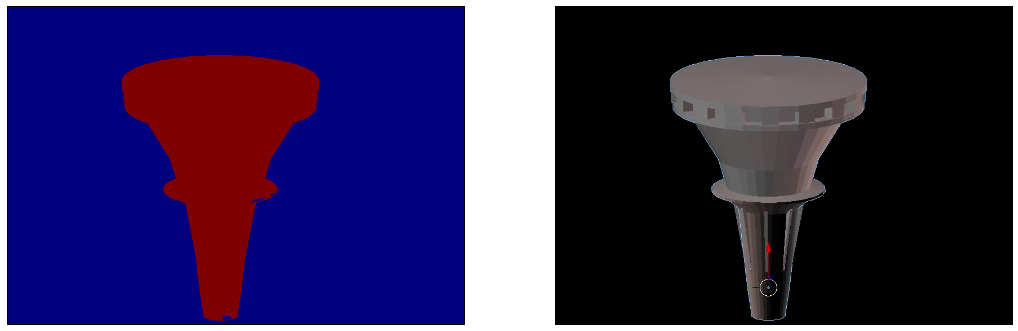

In [13]:
# newmask is the mask image I manually labelled
newmask = cv2.imread('wtmask.jpg',0)

# whereever it is marked white (sure foreground), change mask=1
# whereever it is marked black (sure background), change mask=0
mask[newmask == 0] = 0
mask[newmask == 255] = 1

cv2.grabCut(img,mask,None,
            bgdModel,fgdModel,
            5,cv2.GC_INIT_WITH_MASK)

mask = np.where((mask==2)|(mask==0),0,1).astype('uint8')
img = img*mask[:,:,np.newaxis]

plt.figure(figsize=(18,9))

plt.subplot(121)
plt.imshow(mask),plt.xticks([]),
plt.yticks([])

plt.subplot(122)
plt.imshow(img),plt.xticks([]),
plt.yticks([])

plt.show()
None

ونلاحظ ان النتيجة رائعة , وكل مافعلناه اننا استخدمنا صورة قناع مع تحديد مناطق الخلفية والجسم يدوياً بدون تحديد المستطيل  , ومن ثم طبقنا خوارزمية grabcut مباشرة.

## مراجع اضافية:

## تمارين:

1. تتضمن امثلة OpenCV مثالاً تفاعلياً لاستخدام الخوارزمية السابقة ,ولذلك يمكنك  تعلمها منه  أو مشاهدة مقطع اليوتوب عنه .

2. وهنا ايضاً يمكنك انشاء تطبيق يمكّنك من رسم مستطيل تفاعلياً , ويسمح لك ايضاً برسم خطوط يدوياً ولعرض نتحكم به هن طريق Trackbar .
